In [36]:
import dtlpy as dl
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Access your API key securely
api_key = os.getenv('DTLPY_API_KEY')

print(f"API key: {api_key[:20]}...  ")

# Initialize Dataloop with the API key
dl.login_api_key(api_key=api_key)

API key: eyJ0eXAiOiJKV1QiLCJh...  


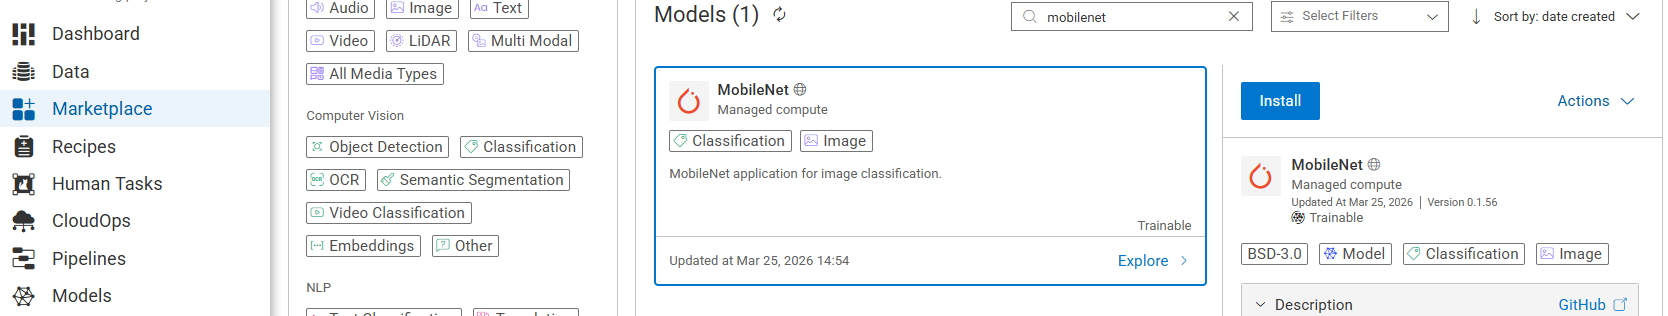

# Install Model from Marketplace

**To install the MobileNet image classifier:**

1. Open the Dataloop Marketplace
2. Click **Explore**
3. Click **Install** on the MobileNet model
4. Click **Add Model** to install it to your project
5. The model will be available in your project and ready for use.

In [37]:
# ============================================================================
# Configuration
# ============================================================================
project_name = "onboarding-project"
dataset_name = "onboarding-dataset"
local_path = r"C:\Users\Yigal_Pinhasi\OneDrive - Dell Technologies\Pictures\dogs"
remote_path = "/specific/folder/new_1"
model_name = "mobilenet"

In [38]:
# ============================================================================
# Project and Dataset Setup
# ============================================================================
# Create your project and dataset (or get if they already exist)

try:
    # Try to get existing project
    project = dl.projects.get(project_name=project_name)
    print(f"Project '{project_name}' already exists")
except Exception:
    # Create project if it doesn't exist
    project = dl.projects.create(project_name=project_name)
    print(f"Created project '{project_name}'")

try:
    # Try to get existing dataset
    dataset = project.datasets.get(dataset_name=dataset_name)
    print(f"Dataset '{dataset_name}' already exists")

except Exception:
    # Create dataset if it doesn't exist
    dataset = project.datasets.create(dataset_name=dataset_name)
    print(f"Created dataset '{dataset_name}'")

Project 'onboarding-project' already exists
Dataset 'onboarding-dataset' already exists


In [39]:
project.models.list().print()


+----+--------------------------+----------------------------------------------------------+---------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [40]:
dataset.items.list().print()


+----+-------------+---------------------------------------------------------------------+-----------------------------------------------+--------+--------------------------+----------+-----------------------+--------------------+-------------------------------------------------------------------+--------------------------+--------------------------+------------------------+------------------------+
|    | annotated   | filename                                                            | name                                          | type   | id                       | hidden   | dir                   |   annotationsCount | dataset                                                           | createdAt                | datasetId                | creator                | updatedBy              |
|----+-------------+---------------------------------------------------------------------+-----------------------------------------------+--------+--------------------------+----------+--------

## Delete all items from dataset remote path

In [41]:
filters = dl.Filters()
filters.add(field='filename', values=remote_path)

print("Items before deletion:", len(dataset.items.list(filters=filters)))
dataset.items.delete(filters=filters)
print("Items after deletion:", len(dataset.items.list(filters=filters)))

Items before deletion: 0
Items after deletion: 0


In [42]:
item = dataset.items.upload(
    local_path= local_path,
    remote_path='/specific/folder',
    overwrite=True  # Optional
)

Upload Items: 100%|██████████| 14/14 [00:03<00:00,  3.22it/s]

[2026-05-14 10:28:21][INF][dtlpy:v1.122.12][repositories.uploader:108] Uploading 14 items..


Upload Items: 100%|██████████| 14/14 [00:03<00:00,  3.73it/s]

[2026-05-14 10:28:21][INF][dtlpy:v1.122.12][repositories.uploader:111] Number of total files: 14
[2026-05-14 10:28:21][INF][dtlpy:v1.122.12][repositories.uploader:115] Number of files overwrite: 14


In [43]:
print("=== Dataset Items ===")
dataset.items.list().print()

print("=== Project ===")
project.print()

print("=== Models ===")
project.models.list().print()

print("=== Apps ===")
project.apps.list().print()

=== Dataset Items ===

+----+-------------+---------------------------------------------------------------------+-----------------------------------------------+--------+--------------------------+----------+-----------------------+--------------------+-------------------------------------------------------------------+--------------------------+--------------------------+------------------------+------------------------+
|    | annotated   | filename                                                            | name                                          | type   | id                       | hidden   | dir                   |   annotationsCount | dataset                                                           | createdAt                | datasetId                | creator                | updatedBy              |
|----+-------------+---------------------------------------------------------------------+-----------------------------------------------+--------+------------------------

In [44]:
# Create list of item IDs from dataset
items = list(dataset.items.list().all())
item_ids = [item.id for item in items]
 
print(f"Total items in dataset: {len(items)}")
print(f"Item IDs: {item_ids}")

Iterate Pages:   5%|▌         | 1/20 [00:00<00:02,  8.44it/s]
Total items in dataset: 20
Item IDs: ['69ee37adc56bbd3672db2647', '69ee37ae32956559ead0162f', '69ee37ae44cb2d314e471e5a', '69ee37ae4bfdf69bfb4c9c66', '69ee37ae937d8985bd14d703', '69ee37af1da1eee1c8ecaf79', '6a057990215ad5000217584e', '6a057990b74d7106145dffb2', '6a057990be71971265e9e037', '6a057990ec389310c57f4063', '6a0579911928feea8bf9cdea', '6a0579911ad4b9b70c9f6dbc', '6a05799137c8930e7e498321', '6a0579913fa3bf87c2f8a152', '6a0579921890819ce5f9edaa', '6a0579922f3ce74fd8bce926', '6a057992873162698605c2f6', '6a0579929eb08624186c030d', '6a05799301b463d64b9e1b83', '6a0579936f59b4549c994527']


In [45]:

model = project.models.get(model_name=model_name)
model.print()


+----+--------------------------+------------------------+-----------+------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [46]:
# Check model deployment status and services
print("Model metadata:")
print(model.metadata)

# Check if there are any services
services = model.metadata.get('system', {}).get('deploy', {}).get('services', [])
print(f"\nNumber of services: {len(services)}")
print(f"Services: {services}")

# List services for this project
print("\nProject services:")
project.services.list().print()

Model metadata:
{'system': {'refs': [{'id': '69ee181a98dcbd406eeff332', 'type': 'app', 'metadata': {'relation': 'createdBy'}}], 'archived': False, 'deploy': {'services': ['6a04629674348c55155701b0', '6a048262bcd2a9ae0ae5fa5f', '6a04862abcd2a9ae0ae5fd37']}}}

Number of services: 3
Services: ['6a04629674348c55155701b0', '6a048262bcd2a9ae0ae5fa5f', '6a04862abcd2a9ae0ae5fd37']

Project services:

+----+------------------------+-----------+-------------------------------------+--------------------------+----------+--------------------------------------+--------------------------------------+--------------------------+----------------------------------------------+-----------------------------------+----------------------------------------------------------+-------------------+-------------------------+--------------------+-------------+-----------+--------------------------+---------------+-----------+-----------------------+------------------------------------------------------------------

In [47]:
# Inspect the actual runtime config of the deployed service
import json

model = project.models.get(model_name=model_name)
service_ids = model.metadata.get('system', {}).get('deploy', {}).get('services', [])
print("Service IDs:", service_ids)

for sid in service_ids:
    s = dl.services.get(service_id=sid)
    print(f"\n=== Service {s.name} ({s.id}) ===")
    print(f"Active: {s.active}")
    print("Runtime:")
    print(json.dumps(s.runtime.to_json() if hasattr(s.runtime, 'to_json') else s.runtime, indent=2, default=str))

Service IDs: ['6a04629674348c55155701b0', '6a048262bcd2a9ae0ae5fa5f', '6a04862abcd2a9ae0ae5fd37']

=== Service predict-69ee181bf7b2015f7c6588-13rm (6a04629674348c55155701b0) ===
Active: True
Runtime:
{
  "podType": "regular-xs",
  "numReplicas": 0,
  "concurrency": 1,
  "autoscaler": {
    "type": "rabbitmq",
    "minReplicas": 0,
    "maxReplicas": 2,
    "cooldownPeriod": 300,
    "pollingInterval": 15,
    "queueLength": 10
  },
  "runnerImage": "dataloop_runner-apps/torch-models:0.1.8",
  "preemptible": true
}

=== Service predict-69ee181bf7b2015f7c6588-qg2d (6a048262bcd2a9ae0ae5fa5f) ===
Active: True
Runtime:
{
  "podType": "regular-xs",
  "numReplicas": 0,
  "concurrency": 1,
  "autoscaler": {
    "type": "rabbitmq",
    "minReplicas": 0,
    "maxReplicas": 2,
    "cooldownPeriod": 300,
    "pollingInterval": 15,
    "queueLength": 10
  },
  "runnerImage": "dataloop_runner-apps/torch-models:0.1.8",
  "preemptible": true
}

=== Service predict-69ee181bf7b2015f7c6588-e7l2 (6a04862a

In [48]:
model.services.list().print()


+----+------------------------+-----------+-------------------------------------+--------------------------+----------+--------------------------------------+--------------------------------------+--------------------------+----------------------------------------------+------------------+----------------------------------------------------------+-------------------+-------------------------+--------------------+-------------+-----------+--------------------------+---------------+----------------------+-------------------------------------------------------------------------------------------------------------------------+----------------+
|    | creator                | version   | name                                | id                       | active   | projectId                            | orgId                                | packageId                | initParams                                   | moduleName       | botUserName                                              | p

In [49]:
import json
 
# model.metadata.print()
print(model.metadata)


{'system': {'refs': [{'id': '69ee181a98dcbd406eeff332', 'type': 'app', 'metadata': {'relation': 'createdBy'}}], 'archived': False, 'deploy': {'services': ['6a04629674348c55155701b0', '6a048262bcd2a9ae0ae5fa5f', '6a04862abcd2a9ae0ae5fd37']}}}


In [50]:
# Delete ALL services for this model
service_ids = list(model.metadata.get('system', {}).get('deploy', {}).get('services', []))

for sid in service_ids:
    try:
        s = dl.services.get(service_id=sid)
        s.delete()
        print(f"Deleted {sid}")
    except Exception as e:
        print(f"Skip {sid}: {e}")

# Refresh model metadata
model = project.models.get(model_name=model.name)
remaining = model.metadata.get('system', {}).get('deploy', {}).get('services', [])
print("Remaining services:", remaining)

Deleted 6a04629674348c55155701b0
Deleted 6a048262bcd2a9ae0ae5fa5f
Deleted 6a04862abcd2a9ae0ae5fd37
Remaining services: []


In [51]:
# First clean up the broken service from previous deploy
model = project.models.get(model_name=model_name)
model.print()

for sid in list(model.metadata.get('system', {}).get('deploy', {}).get('services', [])):
    try:
        dl.services.get(service_id=sid).delete()
        print(f"Deleted {sid}")
    except Exception as e:
        print(f"Skip {sid}: {e}")

# Re-fetch and deploy with a torch-enabled runner image
model = project.models.get(model_name=model_name)
model.print()

service = model.deploy()


print(f"Deployed service: {service.id}, service name: {service.name}")
service.print()


+----+--------------------------+------------------------+-----------+------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [52]:
import time


# Use the ResNet model
model = project.models.get(model_name=model_name)

# Run prediction
prediction = model.predict(item_ids=item_ids)
print(f"Execution id: {prediction.id}")

# Poll status with a max wait time
max_wait_sec = 180
poll_every = 20
deadline = time.time() + max_wait_sec
final_status = None
while time.time() < deadline:
    ex = dl.executions.get(execution_id=prediction.id)
    final_status = ex.latest_status.get('status')
    print(f"  status={final_status}")
    if final_status in ('success', 'failed'):
        break
    time.sleep(poll_every)

print(f"\nFinal status: {final_status}")
if final_status != 'success':
    print("Check logs in dashboard: Cloud Operations -> Services -> Logs")

Execution id: 6a05799923e0e8b933d46826
  status=created
  status=created
  status=created
  status=created
  status=created
  status=in-progress
  status=failed

Final status: failed
Check logs in dashboard: Cloud Operations -> Services -> Logs


In [56]:
# # Run prediction
# model = project.models.get(model_name="mobilenet")

# prediction = model.predict(item_ids=[item_id_1])
# prediction.wait()

# # View results in the web UI
item.open_in_web()


In [55]:
# View prediction results from annotations
print("=== Prediction Results ===")

# Get the items with their annotations
for item_id in item_ids:
    item = dataset.items.get(item_id=item_id)
    print(f"\nItem: {item.name} (ID: {item.id})")
    
    # Get annotations for this item
    annotations = list(item.annotations.list())
    print(f"Number of annotations: {len(annotations)}")


    for annotation in annotations:
        print(f"  Label: {annotation.label}")
        # print(f"  Confidence: {annotation.score}")
        print(f"  Type: {annotation.type}")
        # print(f"  Model: {annotation.model_id}")
        print(f"annotation:{annotation}")

=== Prediction Results ===

Item: dog6.jpg (ID: 69ee37adc56bbd3672db2647)
Number of annotations: 1
  Label: Staffordshire bullterrier, Staffordshire bull terrier
  Type: class
annotation:Annotation(id='6a0579fd09d37d26c49af9ef', item_id='69ee37adc56bbd3672db2647', creator='bot.e44a8309-dff5-4384-ab18-24e314caa4b4@bot.dataloop.ai', created_at='2026-05-14T07:30:05.045Z', type='class', item_height=None, item_width=None, label_suggestions=None, _start_frame=0, _start_time=0)

Item: tabit1.jpg (ID: 69ee37ae32956559ead0162f)
Number of annotations: 1
  Label: wood rabbit, cottontail, cottontail rabbit
  Type: class
annotation:Annotation(id='6a0579fce472f94804637055', item_id='69ee37ae32956559ead0162f', creator='bot.e44a8309-dff5-4384-ab18-24e314caa4b4@bot.dataloop.ai', created_at='2026-05-14T07:30:04.719Z', type='class', item_height=None, item_width=None, label_suggestions=None, _start_frame=0, _start_time=0)

Item: rabit2.jpg (ID: 69ee37ae44cb2d314e471e5a)
Number of annotations: 1
  Label: A